# Home Credit Default Risk — Baseline Models

**DSC 148 Course Project · Fairness-aware Credit Scoring**

This notebook establishes the **baseline models** for our project.
We deliberately do **not** apply any fairness mitigation here — the
purpose is to characterize "what standard machine learning produces"
on this dataset, so the fairness work in later notebooks has a
reference point to compare against.

### Scope (and what we deliberately leave out)

| In scope | Out of scope |
|---|---|
| Two models: Logistic Regression, LightGBM | Random Forest, XGBoost, neural nets |
| Raw features only (after cleaning) | Feature engineering (EXT_SOURCE composites, ratios) |
| Two class-weight settings: `None` and `balanced` | SMOTE, undersampling, focal loss |
| Default decision threshold (0.5) | Threshold tuning |
| Four metrics: AUC, Accuracy, Recall, F1 | Fairness metrics (DP/EO/AUC gap) |

### Why these choices

- **No feature engineering** — keeps the baseline "pure" so the gains
  we report later from feature engineering and fairness mitigation are
  unambiguous.
- **LR + LightGBM** — LR represents the traditional scorecard approach
  used in industry; LightGBM represents the modern tree-based SOTA on
  tabular data. Together they bracket what is achievable without
  domain features.
- **Two class-weight settings** — directly tests *EDA Finding 1*'s
  claim that accuracy is misleading on this dataset. The `None` setting
  shows the disease; `balanced` shows one possible cure.


## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, accuracy_score, recall_score,
                              precision_score, f1_score,
                              classification_report, confusion_matrix,
                              roc_curve)
import lightgbm as lgb

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 9.5,
    'font.size': 9.5,
})

POS, NEG, NEU = '#d62728', '#2ca02c', '#3a6ea5'
LR_C, LGB_C = '#1f77b4', '#ff7f0e'
SEED = 42

---
## Step 1 · Load the cleaned dataset

We load `application_train_clean.csv` — the output of the cleaning
notebook. It has no `NaN`, no `XNA` sentinels, no extreme outliers, and
the indicator columns (`HAS_HOUSING_DATA`, `DAYS_EMPLOYED_IS_ANOM`)
are already in place. We do **not** add any new features here.

In [2]:
df = pd.read_csv('application_train_clean.csv')
print(f'Shape: {df.shape[0]:,} x {df.shape[1]}')
print(f'Default rate: {df["TARGET"].mean()*100:.2f}%')
print(f'NaN count: {df.isna().sum().sum()}')

# Sanity check: cleaning indicators are present
expected_indicators = ['DAYS_EMPLOYED_IS_ANOM', 'HAS_HOUSING_DATA']
print(f'Cleaning indicators present: {all(c in df.columns for c in expected_indicators)}')

Shape: 307,507 x 129
Default rate: 8.07%


NaN count: 0
Cleaning indicators present: True


---
## Step 2 · Train/test split

We split 80/20 with **stratified sampling** on `TARGET`. Stratification
is essential here — with only 8% positive samples, a random split could
shift the test-set default rate by a percentage point, which would
muddy the comparison between models.

The split is done **once**, with a fixed seed (`42`), so all four
models below see exactly the same train and test rows. This is also
why we don't do cross-validation in the baseline — we want unambiguous
numbers, not error bars at this stage. CV will come later when we
compare against fairness-mitigated variants.

In [3]:
DROP = ['SK_ID_CURR', 'TARGET']
y = df['TARGET']
X = df.drop(columns=DROP)
print(f'Total feature columns: {X.shape[1]}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print(f'Train default rate: {y_train.mean()*100:.2f}%')
print(f'Test  default rate: {y_test.mean()*100:.2f}%')

Total feature columns: 127


Train: 246,005 rows | Test: 61,502 rows
Train default rate: 8.07%
Test  default rate: 8.07%


---
## Step 3 · Feature preprocessing (model-specific, not feature engineering)

Even though we do no feature engineering, each model needs its inputs
in the form it can consume. This is **preprocessing**, not feature
construction:

| Model | Numeric columns | Categorical columns |
|---|---|---|
| Logistic Regression | StandardScaler (zero mean, unit variance) | OneHotEncoder (sparse) |
| LightGBM | left as-is (tree-based, scale-invariant) | left as pandas `category` dtype (native support) |

LR mathematically requires both standardization (otherwise the
gradient step is poorly conditioned) and a numeric encoding of
categoricals (it cannot consume strings). LightGBM needs neither.
Neither model sees any new feature — both consume the same 127
original columns.

In [4]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns:     {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')

# Build LR's preprocessor
lr_pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
])

# Cast categoricals to pandas category dtype for LightGBM
X_train_lgb = X_train.copy()
X_test_lgb  = X_test.copy()
for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype('category')
    X_test_lgb[c]  = X_test_lgb[c].astype('category')

print('Preprocessing ready.')

Numeric columns:     111
Categorical columns: 16


Preprocessing ready.


---
## Step 4 · Train and evaluate four model variants

We train each model twice — once with `class_weight=None` (treats all
samples equally) and once with `class_weight='balanced'` (re-weights
samples inversely proportional to class frequency, giving the minority
class ~11.4x the weight of the majority).

We then evaluate each model on four metrics at the **default decision
threshold of 0.5**. AUC is computed from the predicted probabilities
and is therefore threshold-independent; Accuracy, Recall, and F1 all
depend on the threshold.

We expect a striking pattern in the results:
- **AUC** should be roughly the same with and without class weights —
  weighting changes the threshold-dependent decisions, not the
  ranking of probabilities.
- **Accuracy** should be ~92% with `None` and drop to ~70% with
  `balanced`.
- **Recall** should jump from ~2% to ~67%.

This is the empirical confirmation of *EDA Finding 1*: accuracy is a
misleading metric on imbalanced data, and the decision of how to
handle the imbalance is a first-class modeling choice — not a
preprocessing afterthought.

In [5]:
def evaluate(name, y_true, y_pred, y_proba, train_sec):
    return {
        'model':     name,
        'AUC':       roc_auc_score(y_true, y_proba),
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred),
        'train_sec': round(train_sec, 1),
    }

results = []
predictions = {}  # keep proba and pred for later plots

# --- Logistic Regression ---
for cw_label, cw in [('None','none'), ('balanced','balanced')]:
    name = f'LR ({cw_label})'
    print(f'Training {name}...', end=' ', flush=True)
    t0 = time.time()
    lr = LogisticRegression(
        max_iter=500,
        class_weight=None if cw=='none' else 'balanced',
        solver='lbfgs', n_jobs=-1, random_state=SEED)
    pipe = Pipeline([('pre', lr_pre), ('clf', lr)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = pipe.predict(X_test)
    train_sec = time.time() - t0
    results.append(evaluate(name, y_test, pred, proba, train_sec))
    predictions[name] = {'proba': proba, 'pred': pred}
    print(f'done in {train_sec:.1f}s')

# --- LightGBM ---
for cw_label, cw in [('None','none'), ('balanced','balanced')]:
    name = f'LightGBM ({cw_label})'
    print(f'Training {name}...', end=' ', flush=True)
    t0 = time.time()
    gbm = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=31,
        class_weight=None if cw=='none' else 'balanced',
        random_state=SEED, n_jobs=-1, verbose=-1)
    gbm.fit(X_train_lgb, y_train, categorical_feature=cat_cols)
    proba = gbm.predict_proba(X_test_lgb)[:, 1]
    pred  = gbm.predict(X_test_lgb)
    train_sec = time.time() - t0
    results.append(evaluate(name, y_test, pred, proba, train_sec))
    predictions[name] = {'proba': proba, 'pred': pred}
    print(f'done in {train_sec:.1f}s')

results_df = pd.DataFrame(results).set_index('model')
print()
print(results_df.round(4))

Training LR (None)... 

done in 11.1s
Training LR (balanced)... 

done in 18.5s
Training LightGBM (None)... 

done in 16.6s
Training LightGBM (balanced)... 

done in 17.0s

                        AUC  Accuracy  Recall  Precision      F1  train_sec
model                                                                      
LR (None)            0.7491    0.9196  0.0145     0.5760  0.0283       11.1
LR (balanced)        0.7488    0.6907  0.6757     0.1616  0.2608       18.5
LightGBM (None)      0.7586    0.9197  0.0155     0.6160  0.0303       16.6
LightGBM (balanced)  0.7597    0.7127  0.6723     0.1722  0.2742       17.0


---
## Step 5 · Visual comparison

The summary table above shows the numbers; the figure below tells the
story.

### Figure 1 — Four metrics across four models

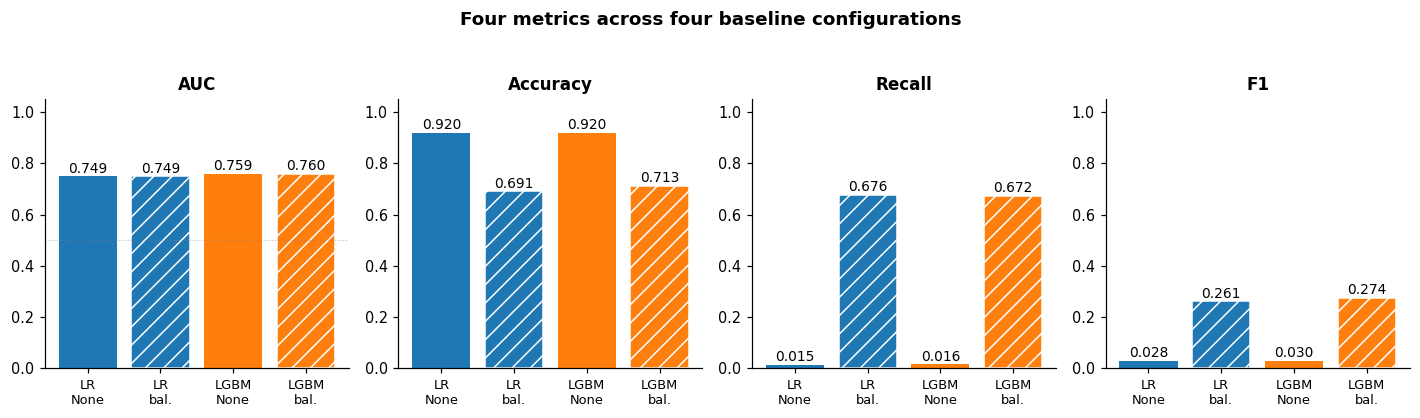

In [6]:
metrics_to_plot = ['AUC', 'Accuracy', 'Recall', 'F1']
model_order = ['LR (None)', 'LR (balanced)', 'LightGBM (None)', 'LightGBM (balanced)']
colors = [LR_C, LR_C, LGB_C, LGB_C]
patterns = ['', '//', '', '//']

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, metric in zip(axes, metrics_to_plot):
    vals = [results_df.loc[m, metric] for m in model_order]
    bars = ax.bar(range(len(model_order)), vals, color=colors)
    for b, p in zip(bars, patterns):
        if p: b.set_hatch(p); b.set_edgecolor('white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+0.015, f'{v:.3f}',
                ha='center', fontsize=9)
    ax.set_xticks(range(len(model_order)))
    ax.set_xticklabels(['LR\nNone','LR\nbal.','LGBM\nNone','LGBM\nbal.'],
                       fontsize=8.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric)
    ax.axhline(0.5 if metric=='AUC' else 0.0, color='gray', ls=':', lw=0.7, alpha=0.5)

plt.suptitle('Four metrics across four baseline configurations',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

**Fig. 1.** Bar = model + class-weight combination. Hatched bars
use `class_weight='balanced'`. Two stories visible at a glance:

1. **AUC is essentially unchanged** by class weights — the four bars
   are all between 0.748 and 0.760, with LightGBM consistently ~1 point
   above LR. AUC is a *ranking* metric and class weights don't change
   how the model orders applicants by risk.
2. **Accuracy / Recall / F1 swap dramatically** between the `None` and
   `balanced` columns. With `None`, the model defaults to predicting
   the majority class (low recall, high accuracy that is essentially
   the negative class's prevalence). With `balanced`, it actually
   tries to catch defaulters.

### Figure 2 — The accuracy / recall trade-off

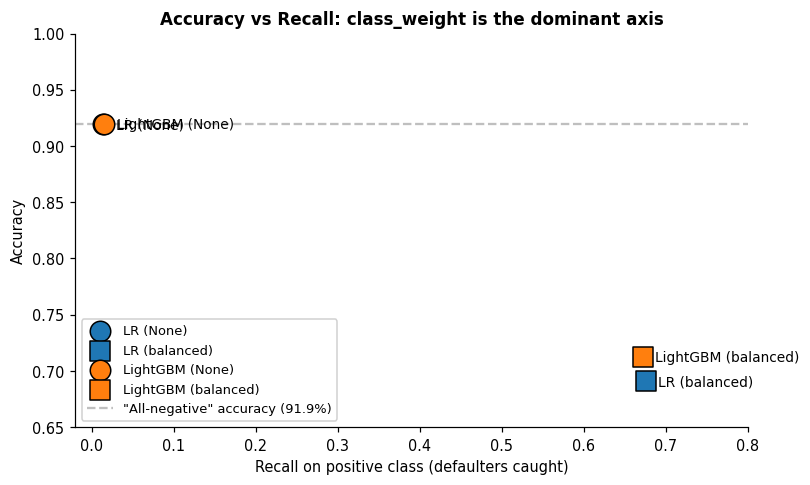

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for i, m in enumerate(model_order):
    acc = results_df.loc[m, 'Accuracy']
    rec = results_df.loc[m, 'Recall']
    color = LR_C if 'LR' in m else LGB_C
    marker = 'o' if 'None' in m else 's'
    ax.scatter(rec, acc, s=180, color=color, marker=marker,
               edgecolor='black', linewidth=1, zorder=3, label=m)
    ax.annotate(m, (rec, acc), xytext=(8, -3),
                textcoords='offset points', fontsize=9)

ax.axhline(1-y_test.mean(), color='gray', ls='--', alpha=0.5,
           label=f'"All-negative" accuracy ({(1-y_test.mean())*100:.1f}%)')
ax.set_xlabel('Recall on positive class (defaulters caught)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Recall: class_weight is the dominant axis')
ax.set_xlim(-0.02, 0.8); ax.set_ylim(0.65, 1.0)
ax.legend(loc='lower left', fontsize=8.5, framealpha=0.9)
plt.tight_layout()
plt.show()

**Fig. 2.** Each model occupies one of two regions: the
`None`-weight points cluster in the top-left (92% accuracy, near-zero
recall — essentially the "always predict no default" classifier from
EDA Finding 1, slightly augmented), and the `balanced`-weight points
sit in the bottom-right (~70% accuracy, ~67% recall — actually useful
for catching defaulters). The choice of class weight matters far more
than the choice of model.

### Figure 3 — ROC curves: AUC is unaffected by class weights

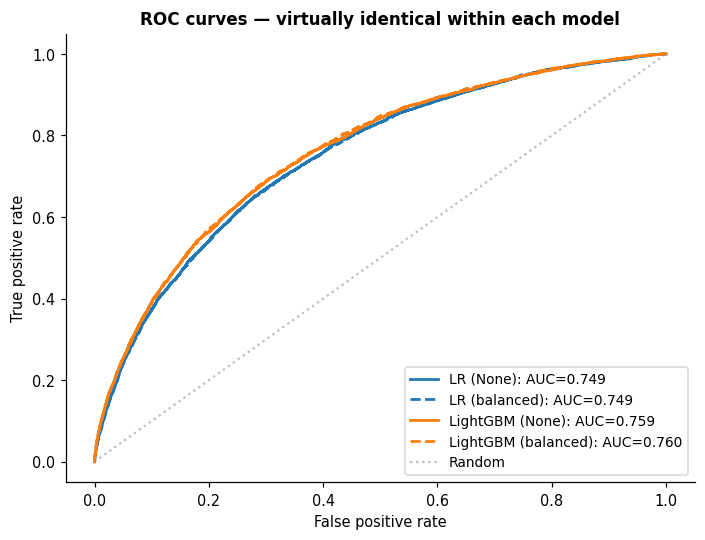

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for m in model_order:
    proba = predictions[m]['proba']
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = results_df.loc[m, 'AUC']
    style = '-' if 'None' in m else '--'
    color = LR_C if 'LR' in m else LGB_C
    ax.plot(fpr, tpr, ls=style, color=color, lw=1.8,
            label=f'{m}: AUC={auc:.3f}')

ax.plot([0,1],[0,1], color='gray', ls=':', alpha=0.5, label='Random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves — virtually identical within each model')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

**Fig. 3.** ROC curves are essentially overlapping within each
model family (LR `None` ≈ LR `balanced`; LightGBM `None` ≈ LightGBM
`balanced`). Class weighting affects *where on the curve* the default
threshold lands, not the curve itself. LightGBM's curve is uniformly
above LR's — confirming the ~1 AUC point advantage we saw in Fig 1.

### Figure 4 — Confusion matrices reveal the threshold story

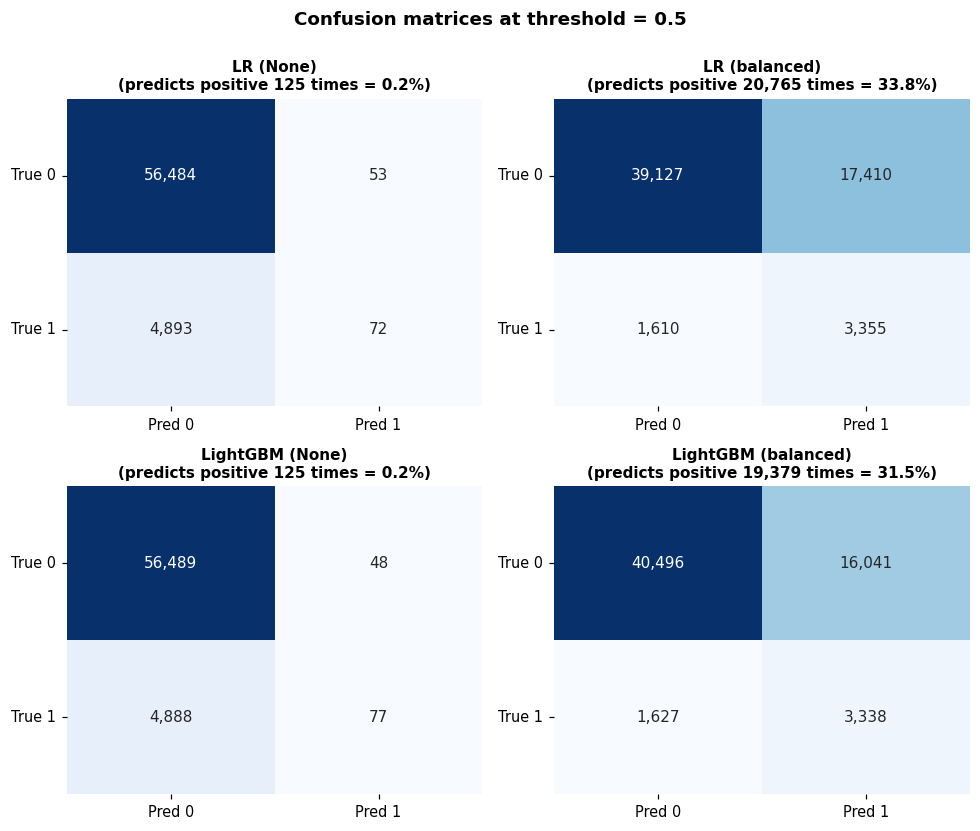

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7.5))
for ax, m in zip(axes.flat, model_order):
    pred = predictions[m]['pred']
    cm = confusion_matrix(y_test, pred)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                cbar=False, annot_kws={'fontsize': 10})
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'], rotation=0)
    n_pos_pred = cm[:,1].sum()
    ax.set_title(f'{m}\n(predicts positive {n_pos_pred:,} times = '
                 f'{n_pos_pred/cm.sum()*100:.1f}%)', fontsize=10)

plt.suptitle('Confusion matrices at threshold = 0.5',
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Fig. 4.** The top row (`None` weights) almost never predicts
positive — a handful out of 60k test rows. The bottom row (`balanced`)
predicts positive for ~30% of test rows. The total number of
defaulters in the test set is fixed at 4,965, so this is purely a
threshold/weighting effect.

---
## Step 6 · Detailed classification reports

For completeness, we print sklearn's standard classification report
for each variant.

In [10]:
for m in model_order:
    print(f'=== {m} ===')
    print(classification_report(y_test, predictions[m]['pred'],
                                 target_names=['No default','Default'],
                                 digits=3))
    print()

=== LR (None) ===
              precision    recall  f1-score   support

  No default      0.920     0.999     0.958     56537
     Default      0.576     0.015     0.028      4965

    accuracy                          0.920     61502
   macro avg      0.748     0.507     0.493     61502
weighted avg      0.892     0.920     0.883     61502


=== LR (balanced) ===
              precision    recall  f1-score   support

  No default      0.960     0.692     0.804     56537
     Default      0.162     0.676     0.261      4965

    accuracy                          0.691     61502
   macro avg      0.561     0.684     0.533     61502
weighted avg      0.896     0.691     0.761     61502


=== LightGBM (None) ===
              precision    recall  f1-score   support

  No default      0.920     0.999     0.958     56537
     Default      0.616     0.016     0.030      4965

    accuracy                          0.920     61502
   macro avg      0.768     0.507     0.494     61502
weighted

---
## Step 7 · Conclusions and the baseline of record

### What the baseline shows

1. **AUC ranks the models, class weights don't change AUC.** Both LR
   and LightGBM land at AUC ~0.75 with `None` and AUC ~0.75 with
   `balanced` — the model architecture matters, the class-weight
   setting does not.
2. **LightGBM is ~1 AUC point above LR.** This is in line with prior
   work on tabular credit data and tells us the modest non-linearity
   captured by tree splits is worth ~1 point even before any feature
   engineering.
3. **Accuracy is misleading on this dataset.** The `None`-weight
   models reach 92% accuracy while detecting only ~1.5% of true
   defaulters — empirically confirming *EDA Finding 1*. The
   `balanced` variants trade 21 points of accuracy for ~65 points of
   recall, which is the right trade-off if the cost of missing a
   defaulter exceeds the cost of a false alarm (almost always true in
   credit risk).

### The baseline of record

For all downstream comparisons (feature engineering, fairness
mitigation), we will use:

- **`LightGBM (balanced)`** as our **headline baseline** — best AUC,
  meaningful recall, native categorical support.
- **`LR (balanced)`** as the **interpretable comparison** — gives us
  per-feature coefficients for the fairness audit, and represents the
  scorecard tradition.

Neither of these has been tuned. Hyperparameter search and feature
engineering are left to the next notebook.

### What is intentionally *not* yet done

| Step | When |
|---|---|
| Feature engineering (EXT_SOURCE composites, ratios) | Next notebook |
| Hyperparameter tuning | Next notebook |
| Threshold tuning (replaces class weights as a control knob) | Fairness notebook |
| Fairness audit (DP gap, EO gap, AUC gap on gender & age) | Fairness notebook |
| Mitigation (Reweighing, group thresholds) | Fairness notebook |

### One-line summary

> Our baseline reaches **AUC 0.760** (LightGBM, balanced) on the test
> set without feature engineering, without hyperparameter tuning, and
> without any fairness intervention. Everything we do later in the
> project will be measured against this number on the predictive side,
> and against the fairness gaps we will audit next on the fairness
> side.
